In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from IPython.display import display

from src.metrics.self_reinforcement import SystemSelfReinforcement, AgentSelfReinforcement

%load_ext autoreload
%autoreload 2

ROOT = Path('..')
BASE = ROOT / 'results' / 'mas' / 'gpqa_full_sim_tier3'

W_VALUES  = [1, 2, 5]
W_COLORS  = {1: '#4C72B0', 2: '#DD8452', 5: '#55A868'}
DS_COLORS = {'gpqa': '#5470C6', 'hiddenbench': '#EE6666'}
datasets  = ['gpqa', 'hiddenbench']

/Users/I550854/Documents/Master Thesis/gdpa-benchmark/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
def load_window_data(w):
    folder = BASE / f'W{w}_fc'
    by_qid = {}
    for f in sorted(folder.glob('*.json')):
        d = json.loads(f.read_text())
        qid = d['question_id']
        if qid not in by_qid or str(f) > by_qid[qid]['_path']:
            d['_path'] = str(f)
            by_qid[qid] = d
    return by_qid

raw = {w: load_window_data(w) for w in W_VALUES}
common_qids = sorted(set(raw[1].keys()) & set(raw[2].keys()) & set(raw[5].keys()))
print(f'Common qids: {len(common_qids)} — {common_qids}')

sys_metric   = SystemSelfReinforcement()
agent_metric = AgentSelfReinforcement()

Common qids: 12 — ['14', '146', '15', '159', '28', '34', '43', '46', '47', '57', '95', '98']


---
# Part 1 — System-Level Self-Reinforcement

## Definition

System-level self-reinforcement measures whether the **group's mean confidence** rises
monotonically as debate progresses, independent of whether agents are changing their minds.

For each (task, config) pair we compute the mean confidence at each round:
$$
\bar{c}_t = \frac{1}{R_t \cdot N} \sum_{r:\,T_r \geq t} \sum_{i=1}^{N} c_{i,t}^{(r)}
$$
where $R_t = |\{r : T_r \geq t\}|$ is the number of repetitions that reached round $t$
(so early-stopped repetitions are excluded once they have stopped, not counted as zero).

We then fit a linear regression
$$
\bar{c}_t = \alpha + \beta_{\text{sys}} \cdot t + \varepsilon_t
$$
and report $\beta_{\text{sys}}$ as the **system-level self-reinforcement slope**.
$\beta_{\text{sys}} > 0$ means the group's expressed confidence grows round-over-round.

The self-reinforcement hypothesis predicts $\beta_{\text{sys}}(w{=}5) > \beta_{\text{sys}}(w{=}2) > \beta_{\text{sys}}(w{=}1)$
because a larger memory window exposes agents to more of their own prior commitments.

### Compute system-level scores

For each (question, W) pair we compute one slope $\beta_\text{sys}$ from the mean-confidence trajectory.

In [3]:
sys_records = []
sys_traj    = []

for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids:
            continue
        reps    = d['repetitions']
        dataset = d.get('dataset', 'unknown')
        result  = sys_metric.score(reps)

        sys_records.append({
            'W': w, 'qid': qid, 'dataset': dataset,
            'beta':  result['beta'],
            'alpha': result['alpha'],
            'n_rounds': len(result['rounds']),
        })

        for t, c, n_r in zip(result['rounds'], result['mean_conf'], result['n_reps_per_round']):
            sys_traj.append({
                'W': w, 'qid': qid, 'dataset': dataset,
                'round': t, 'mean_conf': c, 'n_reps': n_r,
            })

sdf  = pd.DataFrame(sys_records)
stdf = pd.DataFrame(sys_traj)

print(f'Slope records: {len(sdf)}')
print()
display(
    sdf.groupby(['dataset', 'W'])['beta']
    .agg(['mean', 'median', 'std', lambda x: (x > 0).mean()])
    .rename(columns={'<lambda_0>': 'frac_positive'})
    .round(4)
)

Slope records: 36



mean  median     std  frac_positive
dataset     W                                       
gpqa        1  0.2379  0.2168  0.1185            1.0
            2  0.2343  0.2767  0.0809            1.0
            5  0.1308  0.1101  0.0760            1.0
hiddenbench 1  0.0950  0.0886  0.0220            1.0
            2  0.0967  0.0809  0.0305            1.0
            5  0.0868  0.0783  0.0248            1.0

### Distribution of $\beta_\text{sys}$ slopes

How are system-level slopes distributed across questions and memory windows?
A distribution centred at zero would be consistent with no self-reinforcement;
a positive shift confirms the hypothesis.

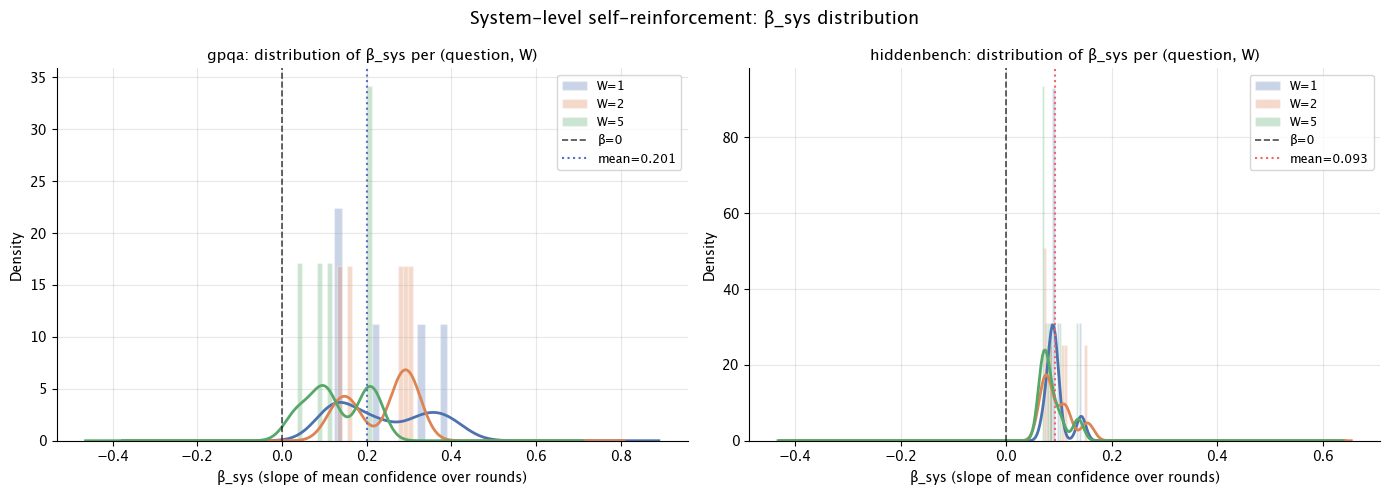


One-sample t-test β_sys > 0:
  gpqa W=1: mean=0.2379  frac_pos=1.00  t=4.49  p=0.0109
  gpqa W=2: mean=0.2343  frac_pos=1.00  t=6.48  p=0.0029
  gpqa W=5: mean=0.1308  frac_pos=1.00  t=3.85  p=0.0183
  hiddenbench W=1: mean=0.0950  frac_pos=1.00  t=11.41  p=0.0000
  hiddenbench W=2: mean=0.0967  frac_pos=1.00  t=8.39  p=0.0002
  hiddenbench W=5: mean=0.0868  frac_pos=1.00  t=9.24  p=0.0001


In [4]:
def kde_line(ax, vals, color, label=None, bw=0.3):
    vals = vals[np.isfinite(vals)]
    if len(vals) < 4:
        return
    kde = gaussian_kde(vals, bw_method=bw)
    xs  = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 400)
    ax.plot(xs, kde(xs), color=color, linewidth=2, label=label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, datasets):
    sub = sdf[sdf['dataset'] == ds]
    for w in W_VALUES:
        vals = sub[sub['W'] == w]['beta'].dropna().values
        ax.hist(vals, bins=15, density=True, alpha=0.3,
                color=W_COLORS[w], edgecolor='white', label=f'W={w}')
        kde_line(ax, vals, W_COLORS[w], bw=0.4)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label='β=0')
    ax.axvline(sub['beta'].mean(), color=DS_COLORS[ds], linewidth=1.5,
               linestyle=':', label=f'mean={sub["beta"].mean():.3f}')
    ax.set_xlabel('β_sys (slope of mean confidence over rounds)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{ds}: distribution of β_sys per (question, W)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('System-level self-reinforcement: β_sys distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nOne-sample t-test β_sys > 0:')
for ds in datasets:
    for w in W_VALUES:
        vals = sdf[(sdf['dataset'] == ds) & (sdf['W'] == w)]['beta'].dropna()
        t, p = sp_stats.ttest_1samp(vals, 0)
        frac  = (vals > 0).mean()
        print(f'  {ds} W={w}: mean={vals.mean():.4f}  frac_pos={frac:.2f}  t={t:.2f}  p={p:.4f}')

### Mean-confidence trajectories per config

Plotting $\bar{c}_t$ over rounds for each (W, dataset) reveals whether confidence
grows steadily, plateaus, or is noisy. Overlaying all three W values on the same
axes also tests the predicted ordering $\beta(w{=}5) > \beta(w{=}2) > \beta(w{=}1)$.

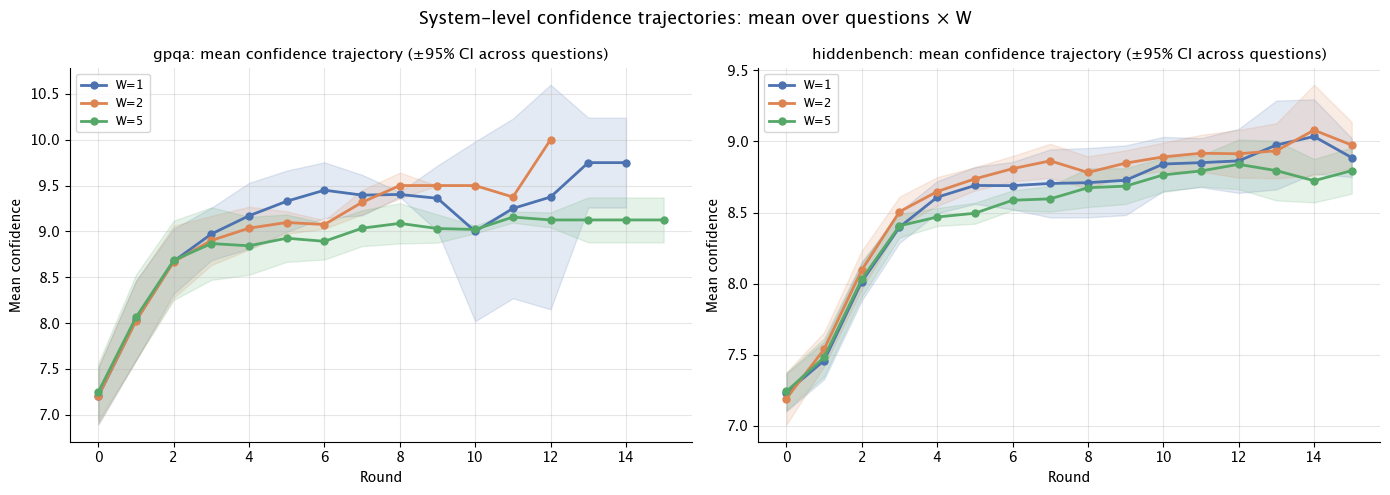

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, datasets):
    sub = stdf[stdf['dataset'] == ds]
    for w in W_VALUES:
        subw = sub[sub['W'] == w].dropna(subset=['mean_conf'])
        grp  = subw.groupby('round')['mean_conf']
        means = grp.mean()
        sems  = grp.sem()
        ax.plot(means.index, means, marker='o', markersize=5,
                color=W_COLORS[w], linewidth=2, label=f'W={w}')
        ax.fill_between(means.index,
                         means - sems * 1.96,
                         means + sems * 1.96,
                         color=W_COLORS[w], alpha=0.15)
    ax.set_xlabel('Round', fontsize=10)
    ax.set_ylabel('Mean confidence', fontsize=10)
    ax.set_title(f'{ds}: mean confidence trajectory (±95% CI across questions)', fontsize=11)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('System-level confidence trajectories: mean over questions × W', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Per-question trajectories

Aggregating hides question-level heterogeneity.
Below we show each question as a separate line, colour-coded by W,
so we can see whether the trajectory shape is consistent or question-specific.

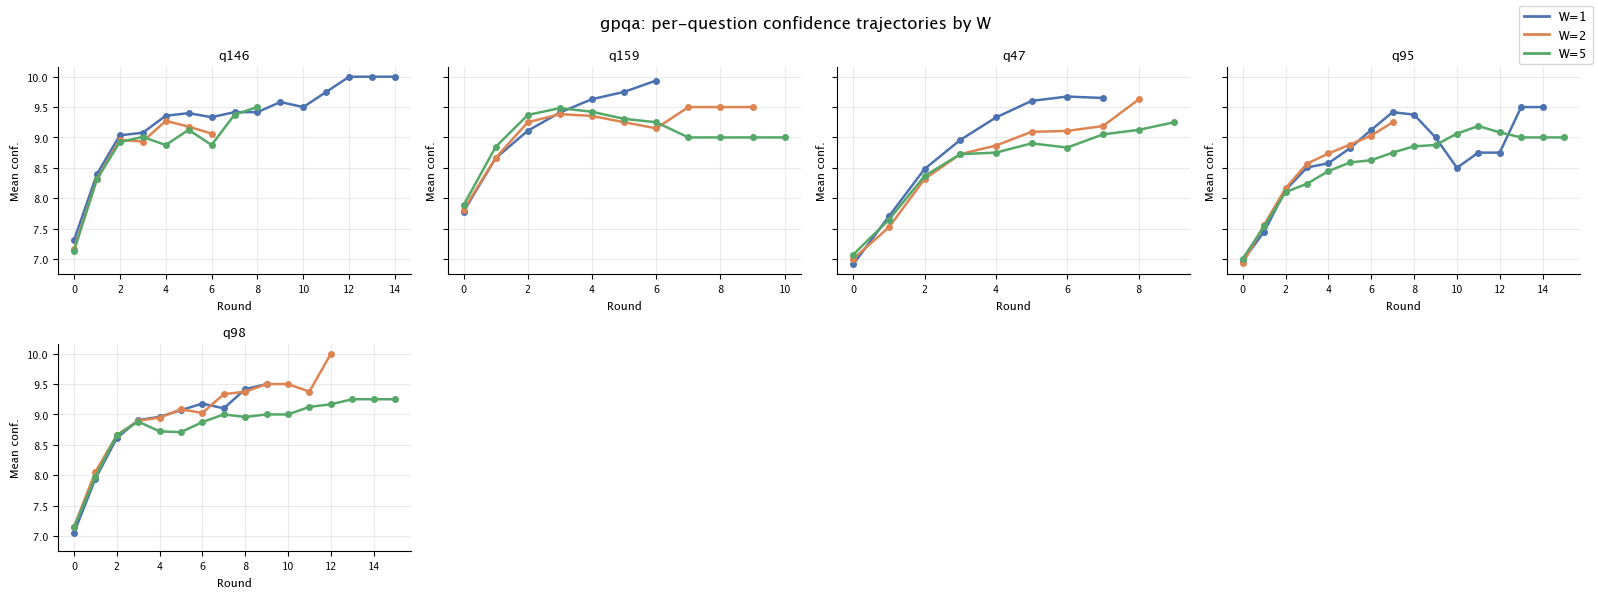

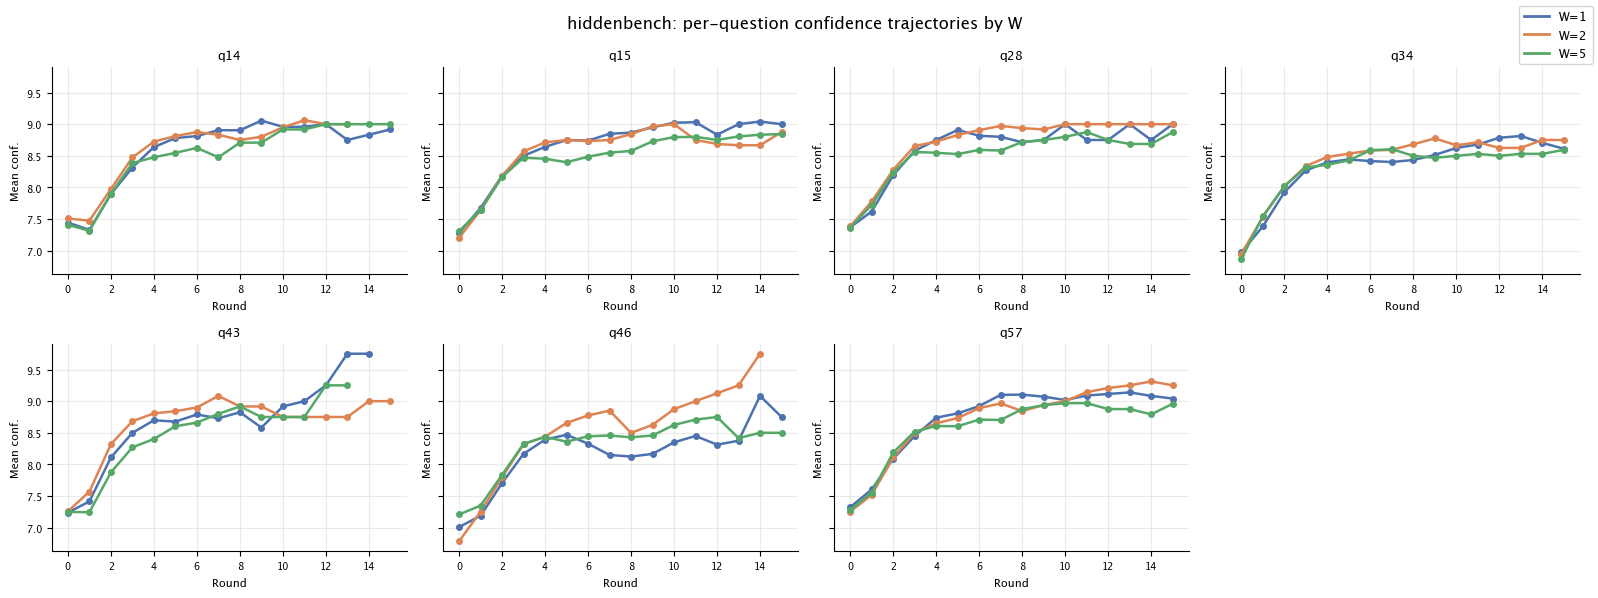

In [6]:
for ds in datasets:
    sub     = stdf[(stdf['dataset'] == ds)].dropna(subset=['mean_conf'])
    q_list  = sorted(sub['qid'].unique())
    n_q     = len(q_list)
    ncols   = 4
    nrows   = int(np.ceil(n_q / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharey=True)
    axes_flat = axes.flatten() if nrows > 1 else axes

    for ax, qid in zip(axes_flat, q_list):
        sq = sub[sub['qid'] == qid]
        for w in W_VALUES:
            swq = sq[sq['W'] == w].sort_values('round')
            if swq.empty:
                continue
            ax.plot(swq['round'], swq['mean_conf'],
                    marker='o', markersize=4, color=W_COLORS[w],
                    linewidth=1.8, label=f'W={w}')
            beta = sdf[(sdf['dataset'] == ds) & (sdf['qid'] == qid) & (sdf['W'] == w)]['beta']
            if len(beta) > 0:
                ax.set_title(f'q{qid}', fontsize=9)
        ax.set_xlabel('Round', fontsize=8)
        ax.set_ylabel('Mean conf.', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes_flat[n_q:]:
        ax.set_visible(False)

    handles = [plt.Line2D([0], [0], color=W_COLORS[w], linewidth=2, label=f'W={w}') for w in W_VALUES]
    fig.legend(handles=handles, loc='upper right', fontsize=9)
    fig.suptitle(f'{ds}: per-question confidence trajectories by W', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### β_sys by W and dataset

Does $\beta_\text{sys}$ increase with larger memory window, as the self-reinforcement
hypothesis predicts? We show boxplots and the mean ± SE.

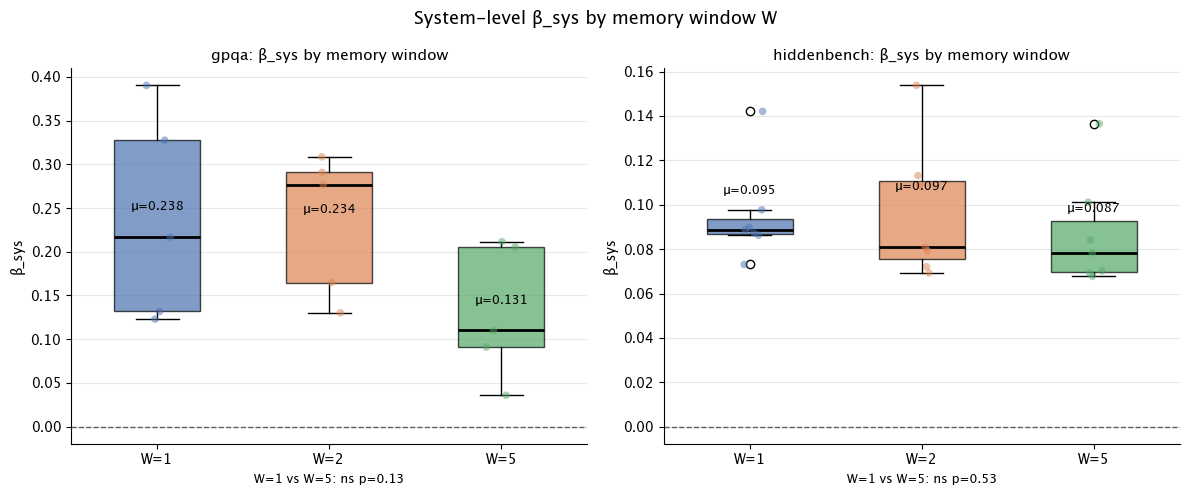


Kruskal-Wallis test across W values:
  gpqa: H=4.340  p=0.1142
  hiddenbench: H=1.989  p=0.3699


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, datasets):
    sub = sdf[sdf['dataset'] == ds]
    data_by_w = [sub[sub['W'] == w]['beta'].dropna().values for w in W_VALUES]
    bp = ax.boxplot(data_by_w, positions=range(len(W_VALUES)),
                    widths=0.5, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, w in zip(bp['boxes'], W_VALUES):
        patch.set_facecolor(W_COLORS[w])
        patch.set_alpha(0.7)
    for i, (vals, w) in enumerate(zip(data_by_w, W_VALUES)):
        ax.scatter(np.random.normal(i, 0.05, len(vals)), vals,
                   color=W_COLORS[w], s=30, alpha=0.5, zorder=3, edgecolors='none')
        ax.text(i, np.nanmean(vals) + 0.01,
                f'μ={np.nanmean(vals):.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xticks(range(len(W_VALUES)))
    ax.set_xticklabels([f'W={w}' for w in W_VALUES], fontsize=10)
    ax.set_ylabel('β_sys', fontsize=10)
    ax.set_title(f'{ds}: β_sys by memory window', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if len(data_by_w[0]) >= 2 and len(data_by_w[-1]) >= 2:
        t, p = sp_stats.ttest_ind(data_by_w[0], data_by_w[-1])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else f'ns p={p:.2f}'
        ax.set_xlabel(f'W=1 vs W=5: {sig}', fontsize=9)

fig.suptitle('System-level β_sys by memory window W', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKruskal-Wallis test across W values:')
for ds in datasets:
    sub = sdf[sdf['dataset'] == ds]
    groups = [sub[sub['W'] == w]['beta'].dropna().values for w in W_VALUES]
    stat, p = sp_stats.kruskal(*groups)
    print(f'  {ds}: H={stat:.3f}  p={p:.4f}')

### Scatter of β_sys across questions — W=1 vs W=5

Each point is a question. The x-axis is its $\beta_\text{sys}$ at W=1 and the y-axis at W=5.
Points above the diagonal have higher self-reinforcement at W=5, as predicted.

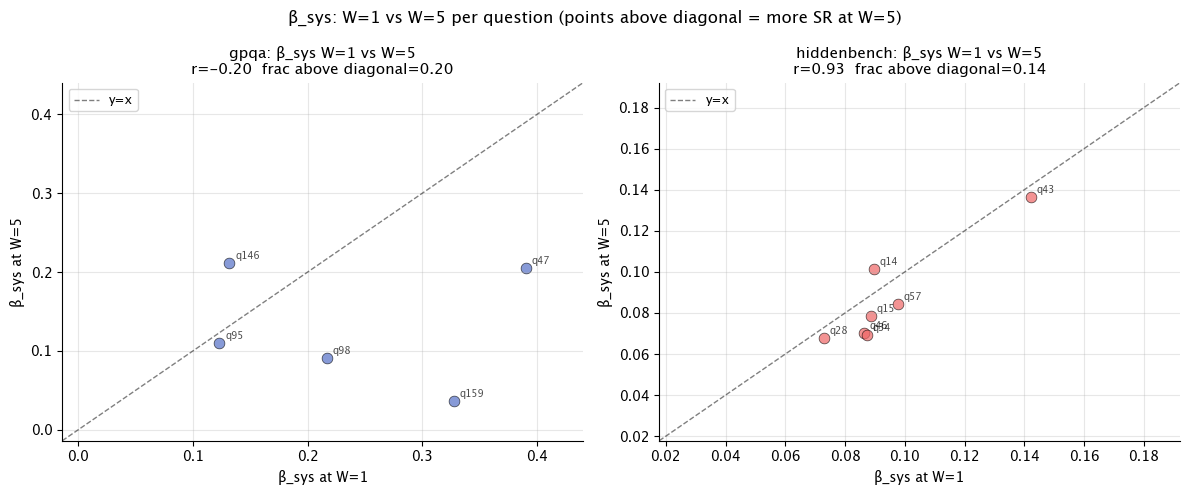

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, datasets):
    sub = sdf[sdf['dataset'] == ds]
    b1  = sub[sub['W'] == 1].set_index('qid')['beta']
    b5  = sub[sub['W'] == 5].set_index('qid')['beta']
    qids_both = b1.index.intersection(b5.index)
    x, y = b1[qids_both].values, b5[qids_both].values
    ax.scatter(x, y, color=DS_COLORS[ds], s=60, alpha=0.7, edgecolors='black', linewidths=0.5)
    for qid, xi, yi in zip(qids_both, x, y):
        ax.annotate(f'q{qid}', (xi, yi), textcoords='offset points',
                    xytext=(4, 3), fontsize=7, alpha=0.7)
    lims = [min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05]
    ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y=x')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    r, p = sp_stats.spearmanr(x, y)
    above = (y > x).mean()
    ax.set_xlabel('β_sys at W=1', fontsize=10)
    ax.set_ylabel('β_sys at W=5', fontsize=10)
    ax.set_title(f'{ds}: β_sys W=1 vs W=5\nr={r:.2f}  frac above diagonal={above:.2f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('β_sys: W=1 vs W=5 per question (points above diagonal = more SR at W=5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 2 — Agent-Level Self-Reinforcement

## Definition

The agent-level analysis zooms in on *individual* vote-stable runs — maximal
consecutive sequences of rounds during which an agent holds the same vote.
Within each such run we fit
$$
c_{i,t}^{(r)} = \alpha_{r,i,s} + \beta_{r,i,s} \cdot (t - s) + \varepsilon_t,
\quad t \in \{s, s+1, \ldots, e\},
$$
retaining only runs with $e - s + 1 \geq 3$ (at least two slope steps).

Each run is annotated with:
- **terminal**: the run ends at the terminal round (i.e., it was still ongoing when the debate stopped, likely due to early stopping)
- **converged**: the agent held the terminal **plurality vote** throughout the run (i.e., it was on the winning side)

Summary statistics:
$$
\hat{p}_{\text{SR}} = \frac{|\{\text{runs with } \beta > 0\}|}{|\text{all runs}|}, \qquad
\bar{\beta}_{\text{agent}} = \frac{1}{|\mathcal{R}|} \sum \beta_{r,i,s}
$$
reported separately for terminal / non-terminal and converged / non-converged runs.

### Compute agent-level scores

In [9]:
agent_records  = []
run_records    = []

for w, data in raw.items():
    for qid, d in data.items():
        if qid not in common_qids:
            continue
        reps    = d['repetitions']
        dataset = d.get('dataset', 'unknown')
        result  = agent_metric.score(reps)

        agent_records.append({
            'W': w, 'qid': qid, 'dataset': dataset,
            'n_runs':              result['n_runs'],
            'p_sr':                result['p_sr'],
            'mean_beta':           result['mean_beta'],
            'p_sr_terminal':       result['p_sr_terminal'],
            'mean_beta_terminal':  result['mean_beta_terminal'],
            'p_sr_nonterminal':    result['p_sr_nonterminal'],
            'mean_beta_nonterminal': result['mean_beta_nonterminal'],
            'p_sr_converged':      result['p_sr_converged'],
            'mean_beta_converged': result['mean_beta_converged'],
            'p_sr_nonconverged':   result['p_sr_nonconverged'],
            'mean_beta_nonconverged': result['mean_beta_nonconverged'],
        })

        for run in result['runs']:
            run_records.append({
                'W': w, 'qid': qid, 'dataset': dataset,
                **{k: run[k] for k in
                   ['rep_idx', 'agent_idx', 'start', 'end', 'run_length',
                    'slope', 'intercept', 'terminal', 'converged', 'vote']}
            })

adf  = pd.DataFrame(agent_records)
rdf  = pd.DataFrame(run_records)

print(f'(question, W) pairs: {len(adf)}')
print(f'Total retained runs:  {len(rdf)}')
print(f'Overall p_SR:         {(rdf["slope"] > 0).mean():.3f}')
print(f'Overall mean β:       {rdf["slope"].mean():.4f}')
print()
display(
    adf.groupby(['dataset', 'W'])[['p_sr', 'mean_beta', 'n_runs']]
    .mean()
    .round(4)
)

(question, W) pairs: 36
Total retained runs:  8140
Overall p_SR:         0.866
Overall mean β:       0.4205



p_sr  mean_beta    n_runs
dataset     W                             
gpqa        1  0.8696     0.5240  214.4000
            2  0.8374     0.4734  212.2000
            5  0.7708     0.4234  216.2000
hiddenbench 1  0.8721     0.3782  248.5714
            2  0.9174     0.4305  225.7143
            5  0.8897     0.3580  229.4286

### Distribution of individual run slopes

Each retained run produces one slope $\beta_{r,i,s}$.
The full distribution across all runs shows whether positive slopes are the norm
or an outlier phenomenon.

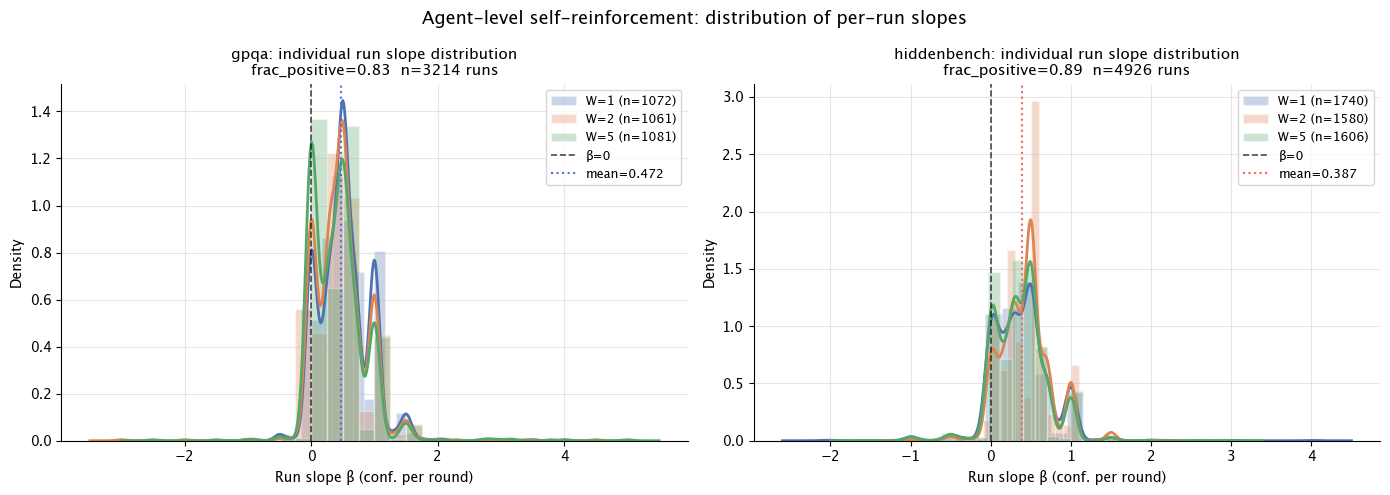


One-sample t-test slope > 0 (all runs pooled):
  gpqa W=1: mean=0.5236  n=1072  t=41.09  p=0.0000
  gpqa W=2: mean=0.4714  n=1061  t=35.58  p=0.0000
  gpqa W=5: mean=0.4206  n=1081  t=30.47  p=0.0000
  hiddenbench W=1: mean=0.3760  n=1740  t=41.75  p=0.0000
  hiddenbench W=2: mean=0.4290  n=1580  t=54.75  p=0.0000
  hiddenbench W=5: mean=0.3581  n=1606  t=42.55  p=0.0000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, datasets):
    sub = rdf[rdf['dataset'] == ds]
    for w in W_VALUES:
        vals = sub[sub['W'] == w]['slope'].dropna().values
        if len(vals) < 4:
            continue
        ax.hist(vals, bins=30, density=True, alpha=0.3,
                color=W_COLORS[w], edgecolor='white', label=f'W={w} (n={len(vals)})')
        kde_line(ax, vals, W_COLORS[w], bw=0.2)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label='β=0')
    ax.axvline(sub['slope'].mean(), color=DS_COLORS[ds], linewidth=1.5,
               linestyle=':', label=f'mean={sub["slope"].mean():.3f}')
    frac_pos = (sub['slope'] > 0).mean()
    ax.set_xlabel('Run slope β (conf. per round)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(
        f'{ds}: individual run slope distribution\n'
        f'frac_positive={frac_pos:.2f}  n={len(sub)} runs',
        fontsize=11
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Agent-level self-reinforcement: distribution of per-run slopes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nOne-sample t-test slope > 0 (all runs pooled):')
for ds in datasets:
    for w in W_VALUES:
        vals = rdf[(rdf['dataset'] == ds) & (rdf['W'] == w)]['slope'].dropna()
        t, p = sp_stats.ttest_1samp(vals, 0)
        print(f'  {ds} W={w}: mean={vals.mean():.4f}  n={len(vals)}  t={t:.2f}  p={p:.4f}')

### Agent-level β vs system-level β

Do (question, W) pairs with a high system-level slope also produce high agent-level slopes?
The two measures should correlate if they reflect the same underlying phenomenon, but
they can diverge when only a minority of agents drive the group mean upward.

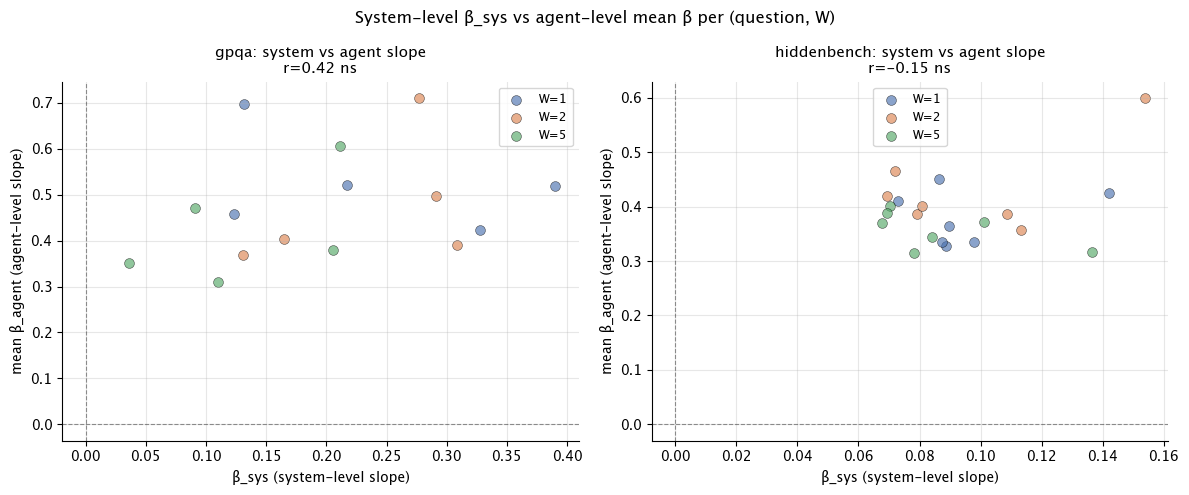

In [11]:
merged = sdf.merge(
    adf[['W', 'qid', 'dataset', 'mean_beta', 'p_sr']],
    on=['W', 'qid', 'dataset'], suffixes=('_sys', '_agent')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, ds in zip(axes, datasets):
    sub = merged[merged['dataset'] == ds]
    for w in W_VALUES:
        subw = sub[sub['W'] == w]
        ax.scatter(subw['beta'], subw['mean_beta'],
                   color=W_COLORS[w], s=50, alpha=0.65,
                   edgecolors='black', linewidths=0.4, label=f'W={w}')
    r, p = sp_stats.spearmanr(sub['beta'], sub['mean_beta'])
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xlabel('β_sys (system-level slope)', fontsize=10)
    ax.set_ylabel('mean β_agent (agent-level slope)', fontsize=10)
    ax.set_title(f'{ds}: system vs agent slope\nr={r:.2f} {sig}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('System-level β_sys vs agent-level mean β per (question, W)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Terminal vs non-terminal runs — prevalence and slopes

A **terminal** run is one that was still ongoing when the debate stopped
(i.e., the agent had not changed its vote before early stopping activated).
We expect terminal runs to have higher $\hat{p}_{\text{SR}}$ because agents that
never flipped have more rounds of unchallenged opinion-holding in which to
escalate their expressed confidence.

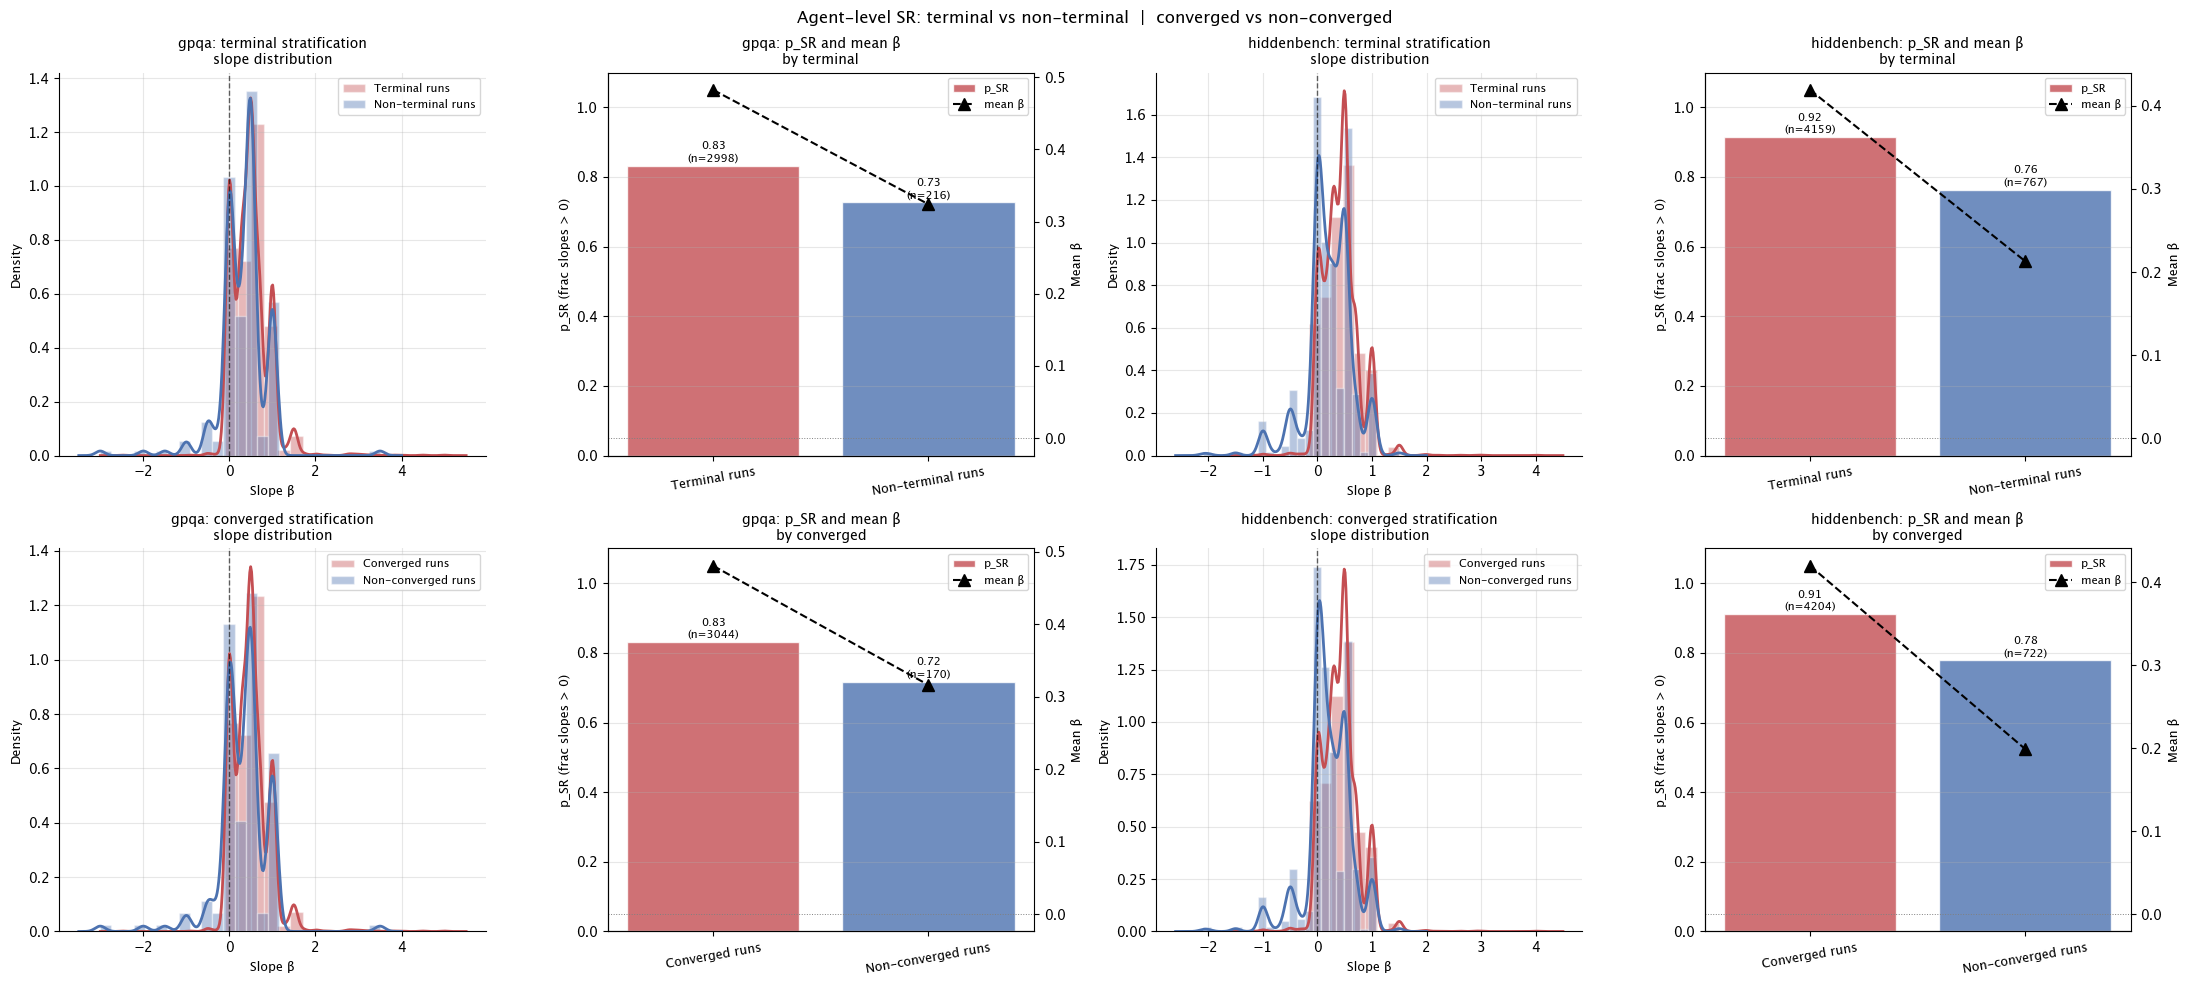


Stratified summary:


,dataset,group,n,p_sr,mean_beta,median_beta
0,gpqa,Terminal runs,2998,0.8326,0.4824,0.5000
1,gpqa,Non-terminal runs,216,0.7269,0.3240,0.4000
2,gpqa,Converged runs,3044,0.8315,0.4804,0.5000
3,gpqa,Non-converged runs,170,0.7176,0.3160,0.4000
4,hiddenbench,Terminal runs,4159,0.9154,0.4193,0.4000
5,hiddenbench,Non-terminal runs,767,0.7640,0.2130,0.2061
6,hiddenbench,Converged runs,4204,0.9113,0.4195,0.4000
7,hiddenbench,Non-converged runs,722,0.7784,0.1987,0.1802


In [12]:
strat_cols = [
    ('terminal',  'Terminal runs', 'Non-terminal runs'),
    ('converged', 'Converged runs', 'Non-converged runs'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for row, (flag, lbl_true, lbl_false) in enumerate(strat_cols):
    for col_idx, (ds, metric_col, ylabel) in enumerate([
        ('gpqa',        'slope', 'Slope β'),
        ('hiddenbench', 'slope', 'Slope β'),
        ('gpqa',        'slope', 'Slope β'),
        ('hiddenbench', 'slope', 'Slope β'),
    ]):
        pass  # placeholder; we build below

    for col_idx, ds in enumerate(datasets):
        sub   = rdf[rdf['dataset'] == ds]
        true_v  = sub[sub[flag] == True]['slope'].dropna()
        false_v = sub[sub[flag] == False]['slope'].dropna()

        ax = axes[row, col_idx * 2]
        for vals, color, lbl in [
            (true_v,  '#C44E52', lbl_true),
            (false_v, '#4C72B0', lbl_false),
        ]:
            if len(vals) >= 4:
                ax.hist(vals, bins=25, density=True, alpha=0.4,
                        color=color, edgecolor='white', label=lbl)
                kde_line(ax, vals.values, color, bw=0.2)
        ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
        ax.set_xlabel('Slope β', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.set_title(f'{ds}: {flag} stratification\nslope distribution', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax = axes[row, col_idx * 2 + 1]
        labels = [lbl_true, lbl_false]
        groups = [true_v, false_v]
        p_pos  = [(g > 0).mean() for g in groups]
        means  = [g.mean() for g in groups]
        ns     = [len(g) for g in groups]
        colors = ['#C44E52', '#4C72B0']
        xs     = np.arange(2)
        bars   = ax.bar(xs, p_pos, color=colors, alpha=0.8, edgecolor='white', label='p_SR')
        ax2    = ax.twinx()
        ax2.plot(xs, means, 'k^--', markersize=8, linewidth=1.5, label='mean β')
        ax2.set_ylabel('Mean β', fontsize=9)
        ax2.axhline(0, color='gray', linewidth=0.7, linestyle=':')
        for i, (p, m, n) in enumerate(zip(p_pos, means, ns)):
            ax.text(i, p + 0.01, f'{p:.2f}\n(n={n})', ha='center', fontsize=8, fontweight='bold')
        ax.set_xticks(xs)
        ax.set_xticklabels(labels, fontsize=9, rotation=10)
        ax.set_ylabel('p_SR (frac slopes > 0)', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_title(f'{ds}: p_SR and mean β\nby {flag}', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        lines1, lbls1 = ax.get_legend_handles_labels()
        lines2, lbls2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, lbls1 + lbls2, fontsize=8)

fig.suptitle('Agent-level SR: terminal vs non-terminal  |  converged vs non-converged', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nStratified summary:')
rows = []
for ds in datasets:
    sub = rdf[rdf['dataset'] == ds]
    for flag, t_lbl, f_lbl in strat_cols:
        for flag_val, lbl in [(True, t_lbl), (False, f_lbl)]:
            g = sub[sub[flag] == flag_val]['slope'].dropna()
            rows.append({
                'dataset': ds, 'group': lbl,
                'n': len(g),
                'p_sr': (g > 0).mean(),
                'mean_beta': g.mean(),
                'median_beta': g.median(),
            })
display(pd.DataFrame(rows).round(4))

### How many runs are terminal, converged, both, or neither?

Understanding the composition of the run pool matters for interpreting the
stratified results above. A majority of terminal runs would mean that most
detected self-reinforcement comes from agents who were never challenged.

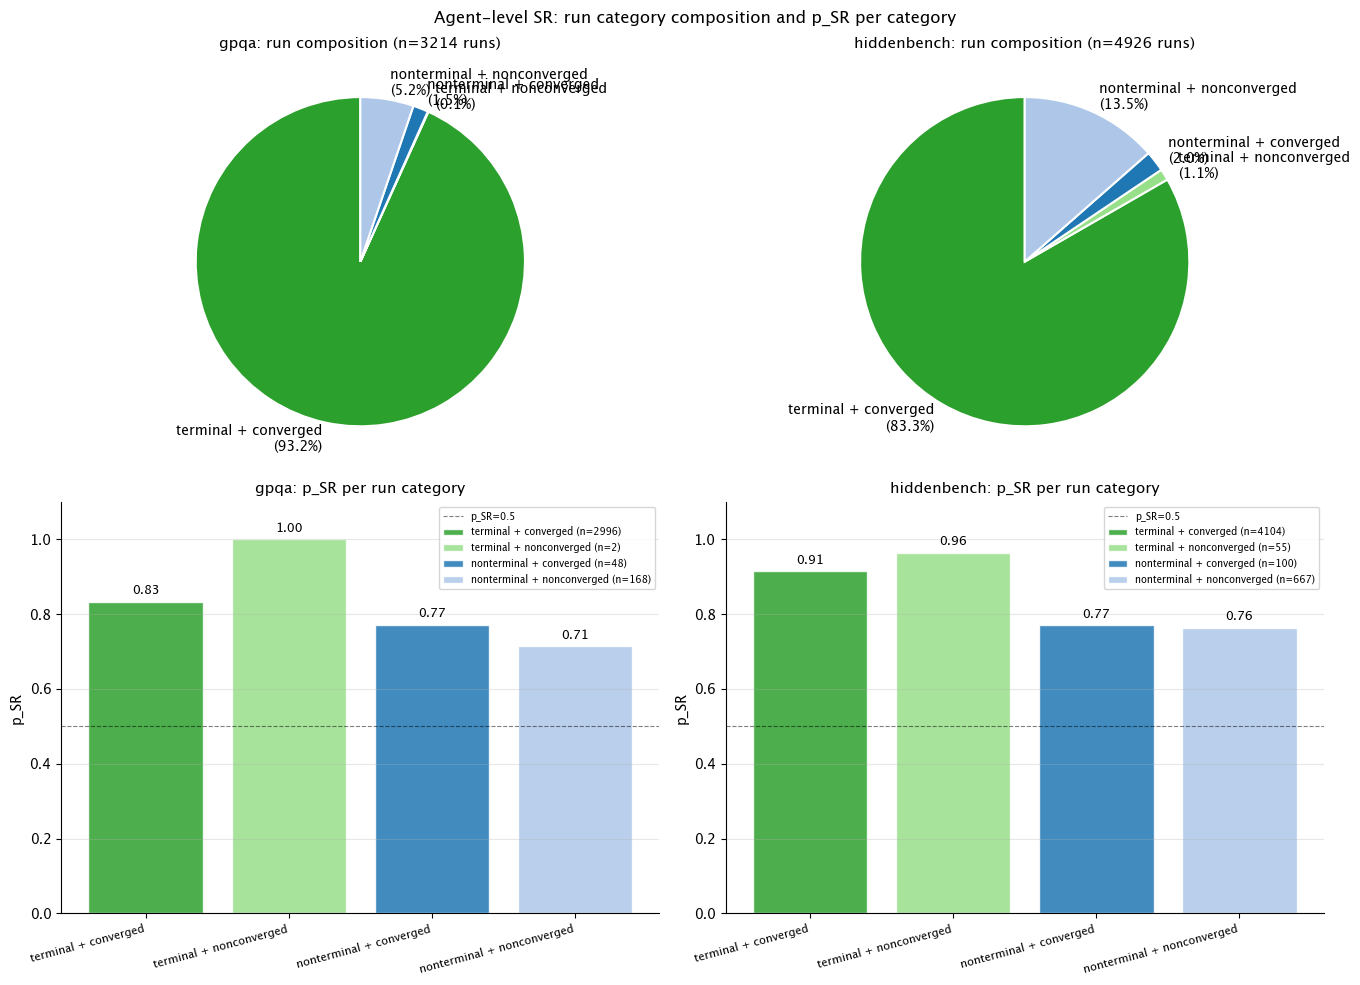


Run category counts and p_SR:


,dataset,category,n,frac_of_total,p_sr,mean_beta
0,gpqa,terminal + converged,2996,0.9322,0.8324,0.4827
1,gpqa,terminal + nonconverged,2,0.0006,1.0000,0.0756
2,gpqa,nonterminal + converged,48,0.0149,0.7708,0.3420
3,gpqa,nonterminal + nonconverged,168,0.0523,0.7143,0.3189
4,hiddenbench,terminal + converged,4104,0.8331,0.9147,0.4237
5,hiddenbench,terminal + nonconverged,55,0.0112,0.9636,0.0900
6,hiddenbench,nonterminal + converged,100,0.0203,0.7700,0.2480
7,hiddenbench,nonterminal + nonconverged,667,0.1354,0.7631,0.2077


In [13]:
rdf['category'] = rdf.apply(lambda r: (
    'terminal + converged'     if r['terminal'] and r['converged'] else
    'terminal + nonconverged'  if r['terminal'] and not r['converged'] else
    'nonterminal + converged'  if not r['terminal'] and r['converged'] else
    'nonterminal + nonconverged'
), axis=1)

cat_order  = ['terminal + converged', 'terminal + nonconverged',
               'nonterminal + converged', 'nonterminal + nonconverged']
cat_colors = ['#2ca02c', '#98df8a', '#1f77b4', '#aec7e8']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col_idx, ds in enumerate(datasets):
    sub = rdf[rdf['dataset'] == ds]

    ax = axes[0, col_idx]
    counts = sub['category'].value_counts().reindex(cat_order, fill_value=0)
    fracs  = counts / counts.sum()
    wedges, texts, autotexts = ax.pie(
        fracs, labels=[f'{c}\n({fracs[c]:.1%})' for c in cat_order],
        colors=cat_colors, autopct='', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    ax.set_title(f'{ds}: run composition (n={len(sub)} runs)', fontsize=11)

    ax = axes[1, col_idx]
    for i, (cat, color) in enumerate(zip(cat_order, cat_colors)):
        vals = sub[sub['category'] == cat]['slope'].dropna()
        if len(vals) < 2:
            continue
        ax.bar(i, (vals > 0).mean(), color=color, alpha=0.85, edgecolor='white',
               label=f'{cat} (n={len(vals)})')
        ax.errorbar(i, (vals > 0).mean(), fmt='none', color='black', capsize=4)
        ax.text(i, (vals > 0).mean() + 0.02,
                f'{(vals > 0).mean():.2f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--', alpha=0.5, label='p_SR=0.5')
    ax.set_xticks(range(len(cat_order)))
    ax.set_xticklabels(cat_order, rotation=15, ha='right', fontsize=8)
    ax.set_ylabel('p_SR', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{ds}: p_SR per run category', fontsize=11)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Agent-level SR: run category composition and p_SR per category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRun category counts and p_SR:')
rows = []
for ds in datasets:
    sub = rdf[rdf['dataset'] == ds]
    for cat in cat_order:
        g = sub[sub['category'] == cat]['slope'].dropna()
        rows.append({
            'dataset': ds, 'category': cat,
            'n': len(g), 'frac_of_total': len(g) / len(sub),
            'p_sr': (g > 0).mean() if len(g) > 0 else np.nan,
            'mean_beta': g.mean() if len(g) > 0 else np.nan,
        })
display(pd.DataFrame(rows).round(4))

### Run length, slope, and W

Longer runs should allow more self-reinforcement to accumulate.
We also check whether the memory window W affects the average run length
(agents with more context may stick to positions longer).

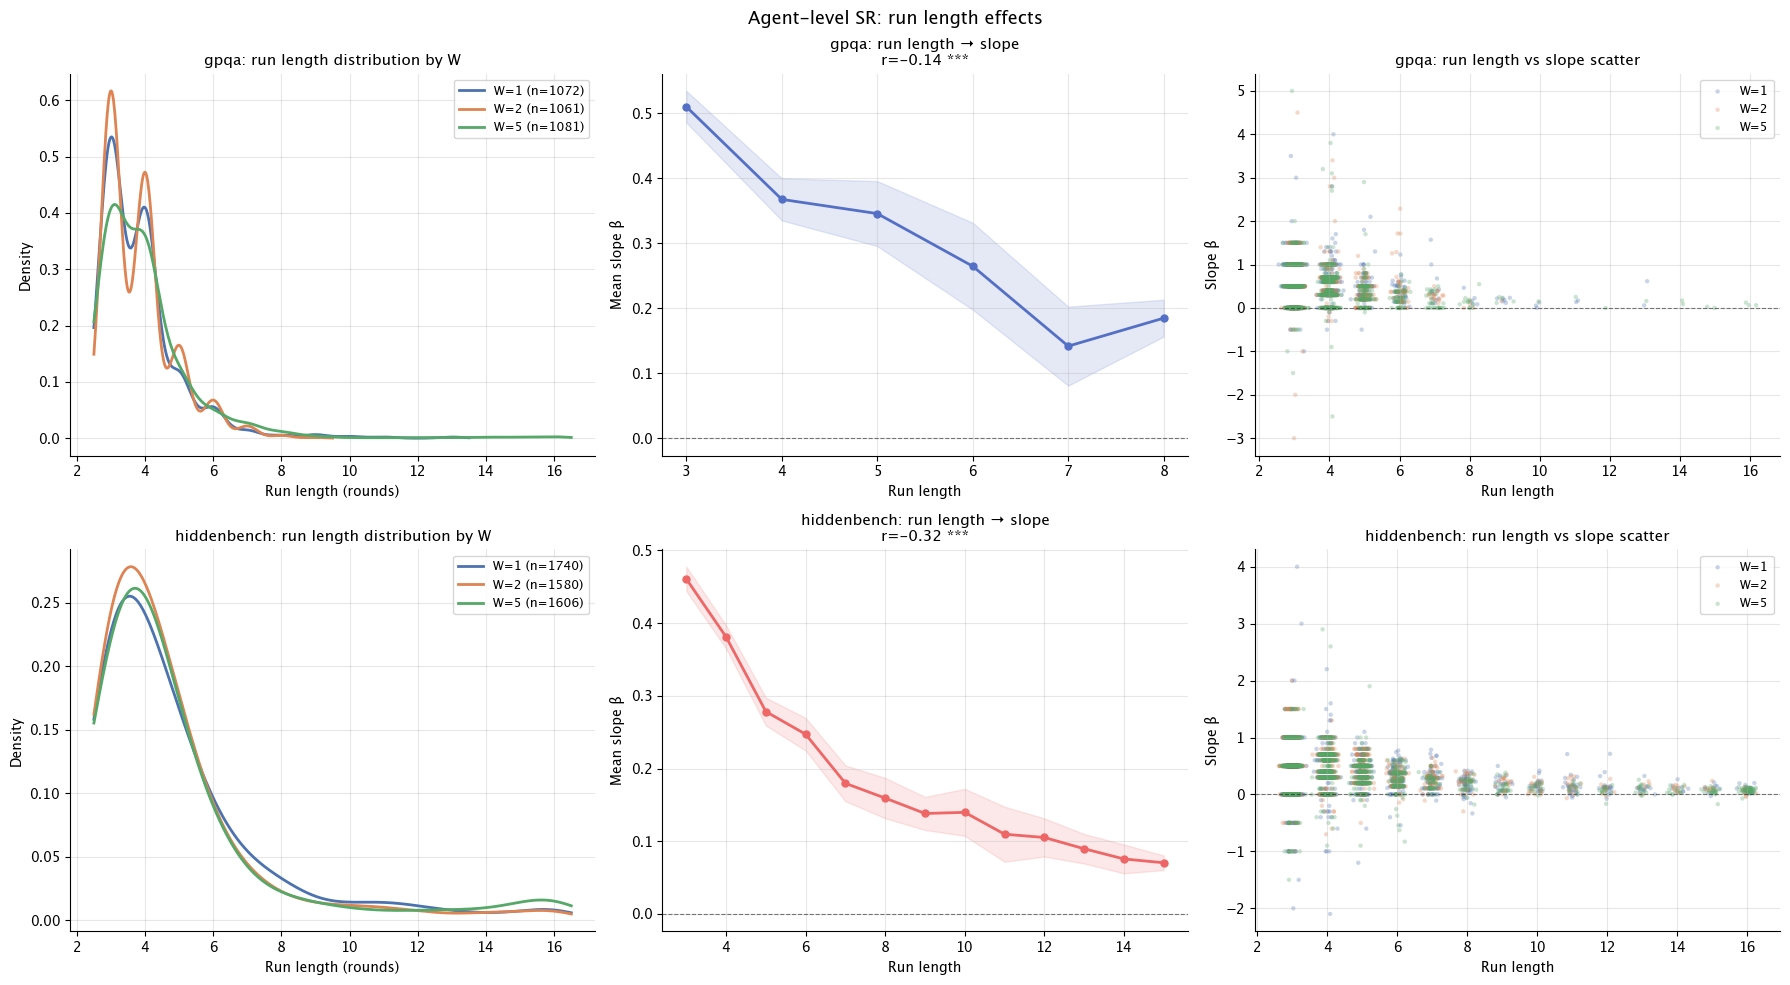

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, ds in enumerate(datasets):
    sub = rdf[rdf['dataset'] == ds]

    ax = axes[row, 0]
    for w in W_VALUES:
        vals = sub[sub['W'] == w]['run_length'].dropna().values
        if len(vals) >= 4:
            kde_line(ax, vals.astype(float), W_COLORS[w], label=f'W={w} (n={len(vals)})')
    ax.set_xlabel('Run length (rounds)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{ds}: run length distribution by W', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[row, 1]
    bins_len = np.arange(3, sub['run_length'].max() + 2)
    lbls     = ((bins_len[:-1] + bins_len[1:]) / 2).astype(int)
    cut      = pd.cut(sub['run_length'], bins=bins_len, labels=lbls)
    grp      = sub.groupby(cut, observed=False)['slope']
    means, sems, ns = grp.mean(), grp.sem(), grp.count()
    valid = ns >= 5
    xs    = means.index.astype(float)[valid]
    ax.plot(xs, means[valid], marker='o', color=DS_COLORS[ds], linewidth=2, markersize=5)
    ax.fill_between(xs, (means - sems * 1.96)[valid], (means + sems * 1.96)[valid],
                    color=DS_COLORS[ds], alpha=0.15)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    r, p = sp_stats.spearmanr(sub['run_length'], sub['slope'])
    sig   = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel('Run length', fontsize=10)
    ax.set_ylabel('Mean slope β', fontsize=10)
    ax.set_title(f'{ds}: run length → slope\nr={r:.2f} {sig}', fontsize=11)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[row, 2]
    for w in W_VALUES:
        subw = sub[sub['W'] == w]
        ax.scatter(
            subw['run_length'] + np.random.normal(0, 0.12, len(subw)),
            subw['slope'],
            color=W_COLORS[w], s=10, alpha=0.3, edgecolors='none', label=f'W={w}'
        )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Run length', fontsize=10)
    ax.set_ylabel('Slope β', fontsize=10)
    ax.set_title(f'{ds}: run length vs slope scatter', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Agent-level SR: run length effects', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Key Findings — Self-Reinforcement Analysis

## Is β_sys > 0 actually a result?

The system-level finding — every (question, W) pair has β_sys > 0 — must be interpreted
carefully. It has a near-trivial confound: the system uses early stopping triggered by vote
consensus, and consensus naturally correlates with high expressed confidence. When a debate
converges, the winning agents have been holding their position for multiple rounds and
plausibly grow more certain. The trajectory β_sys > 0 could therefore simply be saying
*"debates that converge produce confident agents at the end"*, which is expected by design.

The run composition makes this concrete: **93% of retained agent runs in gpqa and 83% in
hiddenbench are terminal+converged** — agents who agreed with the plurality from the start
and held that position until early stopping triggered. The slope of confidence in this dominant
category is inherently confounded with convergence dynamics and cannot be cleanly attributed
to self-reinforcement as a pathology.

The trajectory plots and β_sys distribution are still useful for characterising *how fast*
confidence escalates and *whether W modulates it*, but the headline "β_sys > 0 everywhere"
should not be treated as a clean SR result on its own.

## The non-trivial slice: minority and non-terminal agents

The genuinely interesting sub-population is agents who are **not on the winning side** or
**did not finish the debate still holding the same vote**. These are harder to explain away:

| Group | gpqa p_SR | gpqa mean β | hiddenbench p_SR | hiddenbench mean β |
|---|---|---|---|---|
| Non-terminal | 0.73 | 0.32 | 0.76 | 0.21 |
| Non-converged | 0.72 | 0.32 | 0.78 | 0.20 |

Even agents who eventually flip their vote, or who hold a minority position throughout,
escalate confidence at p_SR ≈ 0.72–0.78. These agents are being challenged — yet they still
express growing certainty. That pattern is harder to attribute to normal convergence and
is the strongest evidence for genuine self-reinforcement in the data.

The gap relative to terminal/converged runs is real (~10pp, ~50% higher mean β), but the
baseline is still well above chance. If SR were purely a convergence artefact, non-terminal
and non-converged runs should show p_SR ≈ 0.5. They do not.

## The W-ordering reversal

The hypothesis predicted β_sys(W=5) > β_sys(W=2) > β_sys(W=1). The data consistently shows
the reverse:

| W | gpqa β_sys | hiddenbench β_sys |
|---|---|---|
| W=1 | **0.238** | 0.095 |
| W=2 | 0.234 | **0.097** |
| W=5 | 0.131 | 0.087 |

80% of gpqa questions and 86% of hiddenbench questions have lower β_sys at W=5 than W=1
(Kruskal-Wallis non-significant: gpqa H=4.34 p=0.11, hiddenbench H=1.99 p=0.37 — directional
trend, not a strong statistical claim).

**Plausible mechanism**: agents with W=1 only see the most recent round, which by round 5+
is already high-confidence (~9+). Their most recent "self" is extremely certain and they
escalate further. Agents with W=5 see their full trajectory including earlier, more uncertain
rounds, which may anchor them slightly. More memory may act as weak self-calibration rather
than amplifying the feedback loop. This reversal is worth reporting but needs the caveat
that it is not significant at conventional thresholds.

## Run length — ceiling effect

Shorter runs have higher slopes (r=−0.14 gpqa, r=−0.32 hiddenbench, both p<0.001): length-3
runs have mean β≈0.5, length 8+ runs have mean β≈0.1. Agents who escalate steeply hit the
confidence ceiling (~10) quickly and the run ends; agents in longer runs grow more slowly
because there is less headroom. SR saturates rather than compounds indefinitely.

## System vs agent correlation

System and agent slopes correlate weakly: r=0.42 (gpqa, ns), r=−0.15 (hiddenbench, ns).
Both measures add independent signal and are worth reporting together.

## What this means for the thesis

The honest framing is: **SR is detectable but mostly confounded at the system level; the
clearest signal is in the non-converged minority**. The system-level β_sys plots and
trajectories are useful descriptives of how the benchmark behaves (rapid early escalation,
plateau, early-stopping lock-in), but they cannot be used as direct evidence of pathological
self-reinforcement without a solo baseline for comparison.

The W-ordering reversal is the most actionable design insight: longer memory does not make
agents more overconfident — it weakly reduces it.

The broader picture that emerges across all three metrics (persuasiveness, alignment, SR)
is consistent: early stopping locks in a consensus quickly, agents on the winning side
converge linguistically and escalate confidence together, while the debate rarely produces
genuine error correction. SR fits into this picture as the confidence dimension of echo-chamber
dynamics, but it needs to be framed carefully rather than presented as a standalone clean result.